In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import scipy.interpolate

In [4]:
files=sorted(glob.glob("../20260430_gw_0.1deg_checks/gen_many/out_limits_ebin0to4*.npz"))
print(f"{len(files)} files found")

290 files found


In [35]:
file=np.load('gw_setup_0.1deg_fix.npz', allow_pickle=True)
ras0=file['ras0']
decs0=file['decs0']
ras=file['ras']
decs=file['decs']
gw_prob=file['gw_prob']
mask_ok=file['mask_ok']
mask_point=file['mask_point']
pointings=file['pointings']

In [8]:
# check which of the simulated signals are inside the ROI
def check_in_roi(ras_true, decs_true):
    rabin=np.digitize (x=ras_true, bins=ras)-1
    decbin=np.digitize (x=decs_true, bins=decs)-1
    mask_ok2=np.zeros((len(decs0)+1, len(ras0)+1), dtype=bool)
    mask_ok2[:-1,:-1]=mask_ok # adding extra overflow bin
    inroi=mask_ok2[decbin, rabin]
    #print(inroi.sum(axis=-1).mean())
    return inroi

In [9]:
# load tables with frequentist method values
ienbin=3
cl=0.95 # only for recomputing frequentist!

truefluxes='0.0 '+' '.join(map(str,np.logspace(-2., 1.,60)))
dirin='./juan_bgd3/'
truefluxes=[a.split('_')[-2][1:] for a in glob.glob(dirin+'/out_freq_f*_s52.npz')]
truefluxes=sorted(truefluxes, key=lambda s: float(s))

file3=np.load(f"{dirin}/out_freq_f0.0_s52.npz")
nullmedians = np.median(file3['tsmax_all'], axis=-1)
print(nullmedians)

tsmax_all=[]
tfs_tab=[]
ras_true_f=[]
decs_true_f=[]
qstab=[]
for tf in truefluxes: 
    file3=np.load(f"{dirin}/out_freq_f{tf}_s52.npz")
    inroi_this=check_in_roi(file3['ras_true'], file3['decs_true'])
    tsmax_this=file3['tsmax_all'][ienbin, inroi_this]
    qstab+= [np.quantile(a=tsmax_this, q=1-cl)]
    tfs_tab+=[float(tf)]
    print(tf, qstab[-1])

[ -5.21286038  -5.10226509  -5.21522763  -5.13618557  -4.48178227
  -4.4423285   -4.54624321  -3.94479299  -4.07241099  -4.03678208
  -3.9142635   -3.44810047  -3.86258781  -5.02331265  -5.6901012
  -6.65281123  -8.42065828  -9.02235848  -9.69878718 -11.95643278
 -11.95643278]
0.0 -8.4137529697927
0.01 -8.30047277833282
0.011242100350620869 -8.322451745437448
0.012638482029342977 -8.3330571701897
0.014208308325339224 -8.292088457991735
0.01597312280060254 -8.305108335494415
0.0179571449437164 -8.2343461835268
0.02018760254679039 -8.200748182622169
0.022695105366946685 -8.137291893834677
0.025514065200312887 -8.245962905720013
0.02868316813342012 -8.176636045329053
0.03224590545296395 -8.077716876077835
0.036251170499885334 -8.062109619799466
0.040753929658717776 -8.054159971879402
0.04581597669054491 -7.988146149068501
0.05150678076168125 -7.780830233014
0.057904439806024895 -7.811299062982116
0.0650967523045817 -7.580786332255161
0.07318242219076174 -7.352616105134506
0.08227241341700

In [25]:
limits_agnostic=[]
limits_bayes=[]
limits_bayes_org=[]
limits_freq=[]
limits_freq_new=[]
fluxes_bayes=[]
fluxtrues=[]
eest=[]
truefluxes=[]
ras_true_all=[]
decs_true_all=[]
for filename in files:
    file=np.load(filename)
    fluxtrue=float((filename.split('_f')[1]).split('_s')[0])
    #fluxtrue+=[file['truefluxes']] # this one is broken in those files
    inroi=check_in_roi(file['ras_true'], file['decs_true'])
    limits_agnostic+=[file['limits_agnostic'][inroi,:]]
    fluxes_bayes+=[file['fluxes_bayes'][inroi,:]]
    limits_freq+=[file['limits_freq'][inroi,:]]
    fluxtrues+=[fluxtrue]*sum(inroi)
    eest+=[file['eest'][:4]]
    ras_true_all+=[file['ras_true'][inroi]]
    decs_true_all+=[file['decs_true'][inroi]]

    #recompute frequentist limits
    file2=np.load('gen_many_freq/'+filename.split('/')[-1])
    ras_true_this=file2['ras_true']
    decs_true_this=file2['decs_true']
    inroi_this=check_in_roi(ras_true_this, decs_true_this)
    tsmaxs_this=file2['maxts0'][inroi_this, ienbin]
    tsmaxs_this=np.where (tsmaxs_this>nullmedians[ienbin], tsmaxs_this, nullmedians[ienbin])
    xx, yy=np.array(sorted(zip(qstab, tfs_tab))).T
    limit2 = np.interp(tsmaxs_this, xx, yy)
    limits_freq_new+=list(limit2)
    
    fs=file['fs']
    lim_bayes=file['limits_bayes'][inroi,:]
    lim_bayes+=np.diff(fs)[0]*0.5
    limits_bayes_org+=[lim_bayes]

    # here we recompute the Bayesian limit in a more accurate way
    fs[1:]+=np.diff(fs)*0.5 # we shift by half a position, to treat the values as the middle of the histogram bin
    pf0s=file['pf0s']
    lim_bayes=np.zeros(file['limits_bayes'].shape)
    for i in range(lim_bayes.shape[0]):
        for j in range(lim_bayes.shape[1]):
            x=pf0s[i,j,:].cumsum()
            y=fs
            iclosest=np.argmin(np.abs(x-0.95))
            i1=np.max([iclosest-1,0])
            i2=np.min([iclosest+2,len(fs)])
            f=scipy.interpolate.PchipInterpolator(x=x[i1:i2], y=y[i1:i2])
            #f=scipy.interpolate.interp1d(x=x[i1:i2], y=y[i1:i2])
            lim_bayes[i,j]=f(0.95)
            #lim_bayes[i,j]=np.interp(xp=x, fp=y, x=0.95)
            
    limits_bayes+=[lim_bayes[inroi,:]]
    
limits_freq_new=np.array(limits_freq_new)
fluxtrues=np.array(fluxtrues)
limits_agnostic=np.concatenate(limits_agnostic, axis=0)
limits_bayes=np.concatenate(limits_bayes)
limits_bayes_org=np.concatenate(limits_bayes_org)
fluxes_bayes=np.concatenate(fluxes_bayes)
limits_freq=np.concatenate(limits_freq)
ras_true_all=np.concatenate(ras_true_all)
decs_true_all=np.concatenate(decs_true_all)
eest=np.array(eest)
#fluxtrues=np.repeat(fluxtrues[..., np.newaxis],limits_agnostic.shape[1], axis=-1)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


0.9461657768656072


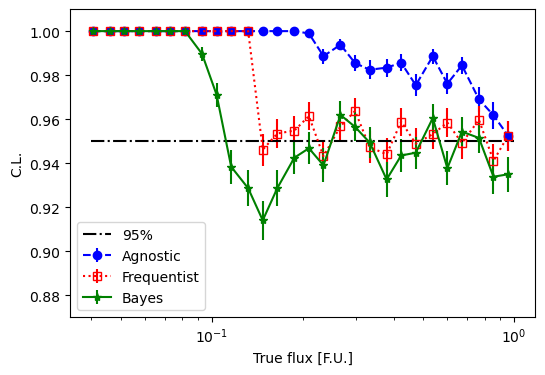

In [28]:
ibin=3
#ibin=1
nflxs=250
flxs=np.logspace(-2, 0, nflxs)
digs=np.digitize(x=fluxtrues, bins=flxs)
fluxplot=[]
fagn=[]
ffreq=[]
ffreq_new=[]
fbayes=[]
fbayesorg=[]
for i in range (1,nflxs):
    flx=np.sqrt(flxs[i-1]*flxs[i]) 
    ok=(digs==i)
    
    if sum(ok):
        fluxplot+=[flx]
        nall=len(limits_agnostic[ok,ibin])
        fagn+=[sum(limits_agnostic[ok,ibin]>fluxtrues[ok])/nall]
        ffreq+=[sum(limits_freq[ok,ibin]>fluxtrues[ok])/nall]
        ffreq_new+=[sum(limits_freq_new[ok]>fluxtrues[ok])/nall]
        fbayes+=[sum(limits_bayes[ok,ibin]>fluxtrues[ok])/nall]
        fbayesorg+=[sum(limits_bayes_org[ok,ibin]>fluxtrues[ok])/nall]
        #print(flx, fagn[-1], ffreq[-1], fbayes[-1])
fagn=np.array(fagn)
ffreq=np.array(ffreq)
ffreq_new=np.array(ffreq_new)
fbayes=np.array(fbayes)
dfang=np.sqrt(fagn*(1-fagn)*nall) / nall
dffreq=np.sqrt(ffreq*(1-ffreq)*nall) / nall
dffreq_new=np.sqrt(ffreq_new*(1-ffreq_new)*nall) / nall
dfbayes=np.sqrt(fbayes*(1-fbayes)*nall) / nall

print(np.mean(fbayes[-13:]))
plt.figure(figsize=(6,4))
plt.errorbar(fluxplot, fagn, yerr=dfang, fmt='o--b', label="Agnostic")
#plt.errorbar(fluxplot, ffreq, yerr=dffreq, fmt='s:r', mfc='none', label="Frequentist")
plt.errorbar(fluxplot, ffreq_new, yerr=dffreq_new, fmt='s:r', mfc='none', label="Frequentist")
plt.errorbar(fluxplot, fbayes,yerr=dfbayes, fmt='*-g', label="Bayes")
#plt.plot(fluxplot, fbayesorg, '*m', label="Bayes org")
plt.plot([0.04, 1.], [0.95, 0.95], '-.k', label="95%")
plt.xscale('log')
plt.xlabel('True flux [F.U.]')
plt.ylabel("C.L.")
plt.legend()
#plt.ylim(0.7, 1.01)
plt.ylim(0.87, 1.01)
plt.savefig('comp_tilepy_cl.eps')
plt.show()

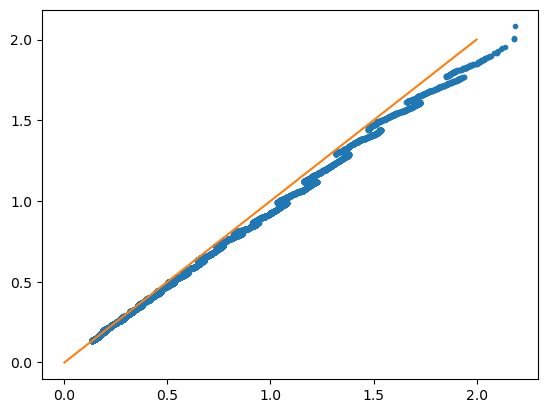

In [30]:
plt.plot(limits_freq[:,ienbin], limits_freq_new, '.')
plt.plot([0,2], [0,2])
plt.show()

In [31]:
np.abs(decs_true_all[:, np.newaxis]- decs0[np.newaxis, :]).min(axis=-1).std()

0.0

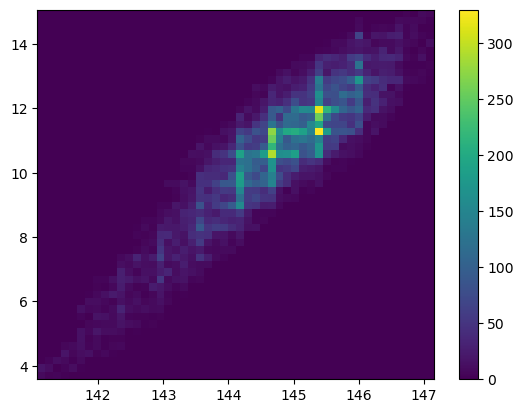

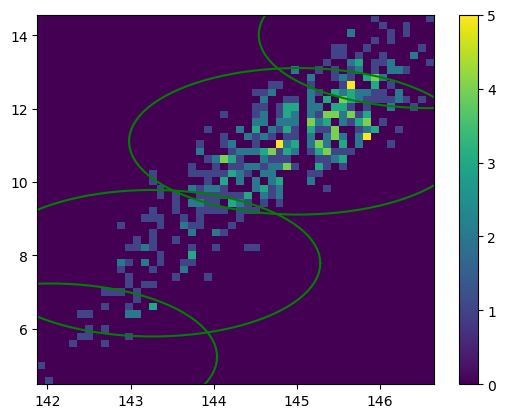

In [36]:
cuts=(fluxtrues>0.3) * (limits_bayes[:,ibin]<fluxtrues)

plt.figure()
plt.hist2d(ras_true_all, decs_true_all, bins=(50,50))
plt.colorbar()
plt.show()
plt.figure()
plt.hist2d(ras_true_all[cuts], decs_true_all[cuts], bins=(50,50))
plt.colorbar()


for ra,dec in pointings:
    radius=2.
    angles=np.linspace(0, 2*np.pi,100)
    x=ra+radius*np.cos(angles)/np.cos(np.radians(dec))
    y=dec+radius*np.sin(angles)
    plt.plot(x,y, c='g')
plt.show()



0.06309573332242291 0.0


/tmp/ipykernel_641584/1335665170.py:13: RuntimeWarning: divide by zero encountered in log10
  sm=ax.hist2d(np.log10(fluxtrues), np.log10(limits_agnostic[:,ibin]), bins=[np.linspace(np.log10(minplot),np.log10(maxplot), nplot), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
/tmp/ipykernel_641584/1335665170.py:21: RuntimeWarning: divide by zero encountered in log10
  sm=ax.hist2d(np.log10(fluxtrues), np.log10(limits_freq_new), bins=[np.linspace(np.log10(minplot),np.log10(maxplot), nplot), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
/tmp/ipykernel_641584/1335665170.py:28: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d(np.log10(fluxtrues), np.log10(limits_bayes[:,ibin]), bins=[np.linspace(np.log10(minplot),np.log10(maxplot), nplot), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')


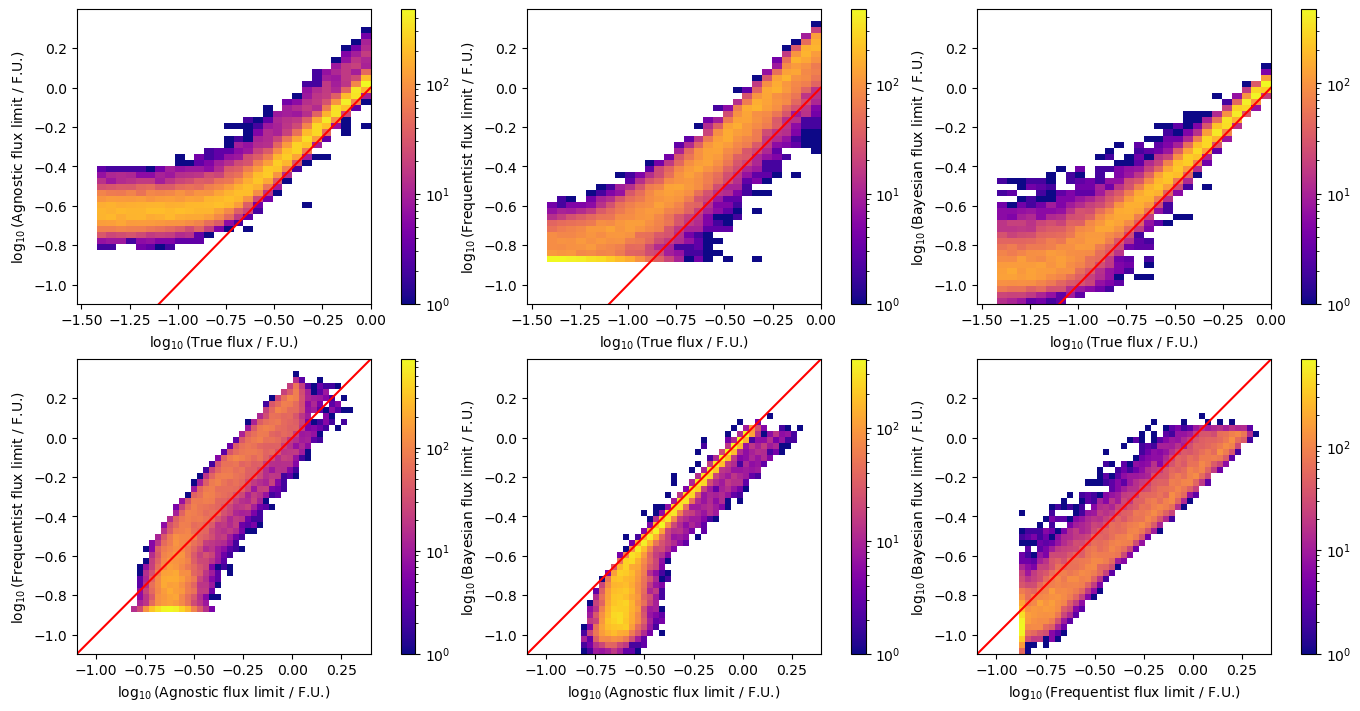

In [38]:
ibin=3 # paper

minplot=0.03
maxplot=1.
nplot=31
miny=0.08
maxy=2.5
cmap='plasma'
print(eest[:,ibin].mean(), eest[:,ibin].std())
fig, axs = plt.subplots(2, 3, figsize=(3*4.5,2*3.5),layout="constrained")
#fig.tight_layout()
ax=axs[0,0]
sm=ax.hist2d(np.log10(fluxtrues), np.log10(limits_agnostic[:,ibin]), bins=[np.linspace(np.log10(minplot),np.log10(maxplot), nplot), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
plt.colorbar(sm[3],ax=ax)
ax.plot([-2, 0], [-2,0], 'r')
ax.set_xlabel(r"$\log_{10}$(True flux / F.U.)")
ax.set_ylabel(r"$\log_{10}$(Agnostic flux limit / F.U.)")

ax=axs[0,1]
#sm=ax.hist2d(np.log10(fluxtrues), np.log10(limits_freq[:,ibin]), bins=[np.linspace(np.log10(minplot),np.log10(maxplot), nplot), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
sm=ax.hist2d(np.log10(fluxtrues), np.log10(limits_freq_new), bins=[np.linspace(np.log10(minplot),np.log10(maxplot), nplot), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
plt.colorbar(sm[3],ax=ax)
ax.plot([-2, 0], [-2,0], 'r')
ax.set_xlabel(r"$\log_{10}$(True flux / F.U.)")
ax.set_ylabel(r"$\log_{10}$(Frequentist flux limit / F.U.)")

ax=axs[0,2]
ax.hist2d(np.log10(fluxtrues), np.log10(limits_bayes[:,ibin]), bins=[np.linspace(np.log10(minplot),np.log10(maxplot), nplot), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
plt.colorbar(sm[3],ax=ax)
ax.plot([-2, 0], [-2,0], 'r')
ax.set_xlabel(r"$\log_{10}$(True flux / F.U.)")
ax.set_ylabel(r"$\log_{10}$(Bayesian flux limit / F.U.)")

ax=axs[1,0]
#sm=ax.hist2d(np.log10(limits_agnostic[:,ibin]), np.log10(limits_freq[:,ibin]), bins=[np.linspace(np.log10(miny),np.log10(maxy), 50), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
sm=ax.hist2d(np.log10(limits_agnostic[:,ibin]), np.log10(limits_freq_new), bins=[np.linspace(np.log10(miny),np.log10(maxy), 50), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
plt.colorbar(sm[3],ax=ax)
ax.plot([np.log10(miny), np.log10(maxy)], [np.log10(miny), np.log10(maxy)], 'r')
ax.set_xlabel(r"$\log_{10}$(Agnostic flux limit / F.U.)")
ax.set_ylabel(r"$\log_{10}$(Frequentist flux limit / F.U.)")

ax=axs[1,1]
sm=ax.hist2d(np.log10(limits_agnostic[:,ibin]), np.log10(limits_bayes[:,ibin]), bins=[np.linspace(np.log10(miny),np.log10(maxy), 50), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
plt.colorbar(sm[3],ax=ax)
ax.plot([np.log10(miny), np.log10(maxy)], [np.log10(miny), np.log10(maxy)], 'r')
ax.set_xlabel(r"$\log_{10}$(Agnostic flux limit / F.U.)")
ax.set_ylabel(r"$\log_{10}$(Bayesian flux limit / F.U.)")

ax=axs[1,2]
#sm=ax.hist2d(np.log10(limits_freq[:,ibin]), np.log10(limits_bayes[:,ibin]), bins=[np.linspace(np.log10(miny),np.log10(maxy), 50), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
sm=ax.hist2d(np.log10(limits_freq_new), np.log10(limits_bayes[:,ibin]), bins=[np.linspace(np.log10(miny),np.log10(maxy), 50), np.linspace(np.log10(miny),np.log10(maxy), 50)], cmap=cmap, cmin=0.1, norm='log')
plt.colorbar(sm[3],ax=ax)
ax.plot([np.log10(miny), np.log10(maxy)], [np.log10(miny), np.log10(maxy)], 'r')
ax.set_xlabel(r"$\log_{10}$(Frequentist flux limit / F.U.)")
ax.set_ylabel(r"$\log_{10}$(Bayesian flux limit / F.U.)")
plt.savefig("comp_tilepy.eps")
plt.show()

0.0 832 141 0
0.040753929658717776 829 131 0
0.04581597669054491 846 119 0
0.05150678076168125 836 126 0
0.057904439806024895 827 141 0
0.0650967523045817 839 134 0
0.07318242219076174 827 148 0
0.0822724134170047 834 126 0
0.09249147277217336 823 144 0
0.103979841848149 828 140 0
0.11689518164985782 809 148 0
0.13141473626117567 813 153 0
0.1477377652598511 815 147 3
0.1660882782627716 799 165 3
0.18671810912919207 817 147 9
0.20991037201085547 812 127 19
0.2359833466782195 824 126 17
0.26529484644318974 813 120 38
0.2982471286216891 831 98 36
0.3352924149249558 822 95 51
0.37693909753883614 814 89 61
0.4237587160604063 814 74 85
0.4763938010401343 810 81 86
0.5355666917706899 785 66 110
0.6020894493336132 781 66 116
0.6768750009458534 766 64 133
0.7609496685459879 779 52 137
0.8554672535565685 777 56 134
0.9617248711152965 786 52 130


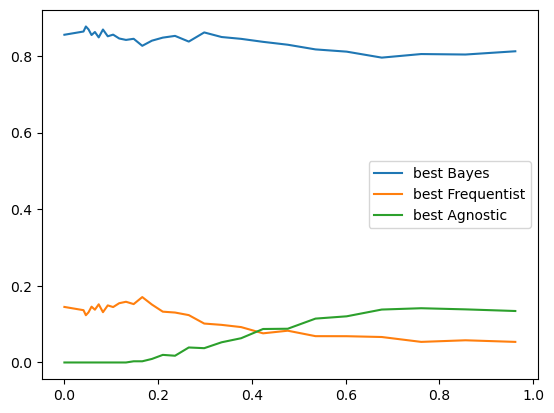

In [11]:
ff=np.array(sorted(list(set(fluxtrues))))
bestbayes=[]
bestfreq=[]
bestagn=[]
for f in ff:
    mask=fluxtrues==f
    f1=sum(((limits_bayes<=limits_freq)*(limits_bayes<=limits_agnostic))[mask,ibin])
    f2=sum(((limits_freq<=limits_bayes)*(limits_freq<=limits_agnostic))[mask,ibin])
    f3=sum(((limits_agnostic<=limits_bayes)*(limits_agnostic<=limits_freq))[mask,ibin])
    bestbayes+=[f1/(f1+f2+f3)]
    bestfreq+=[f2/(f1+f2+f3)]
    bestagn+=[f3/(f1+f2+f3)]
    print(f, f1,f2, f3)

plt.plot(ff, bestbayes, label="best Bayes")
plt.plot(ff, bestfreq, label="best Frequentist")
plt.plot(ff, bestagn, label="best Agnostic")
plt.legend()
plt.show()

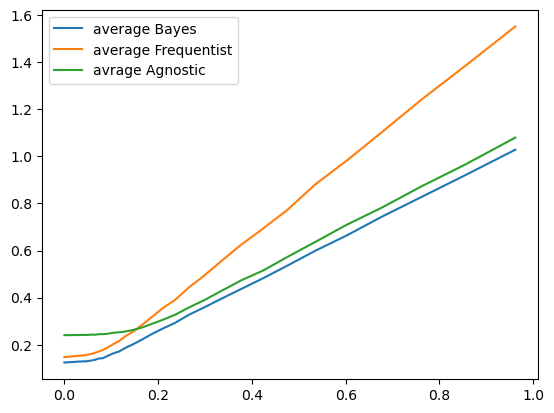

In [12]:
ff=np.array(sorted(list(set(fluxtrues))))
avrbayes=[]
avrfreq=[]
avragn=[]
for f in ff:
    mask=fluxtrues==f
    avrbayes+=[limits_bayes[mask,ibin].mean()]
    avrfreq+=[limits_freq[mask,ibin].mean()]
    avragn+=[limits_agnostic[mask,ibin].mean()]

plt.plot(ff, avrbayes, label="average Bayes")
plt.plot(ff, avrfreq, label="average Frequentist")
plt.plot(ff, avragn, label="avrage Agnostic")
plt.legend()
plt.show()